This notebook aims to create a spectral classifier for stellar spectrums   
(Classifying a star into OBAFGKM based on their spectra)

# Imports

In [2]:
from astroquery.sdss import SDSS
from astropy.io import fits

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d

import datetime
import os
import re
import joblib

In [3]:
data_dir = "../data/starspectra"
data_output_dir = "../data_output/starspectra"

# Get Data   

Here we get data from (Server -> Local)  
we choose SDSS (Sloan Digital Sky Survey), based in New Mexico, US to get a catalog of stars  

We access it through astroquery.sdss

## Get metadata info from SDSS

The goal of this step is to get metadata about the star, things like ID, plate number, fiber number etc. to identify the star and locate its spectra, also the label it has been assigned, major class, luminosity class and other features as needed  
you can actually query and inspect the data directly at CasJobs as well  
The following query seems quite long - but it was just ensure i was sampling the data properly  
we do DR17 because thats what i believe astroquery was fetching FITS file from - I'll figure out DR19 and update this later    

In [ ]:
query = """
WITH FilteredStars AS (
  SELECT
    bestObjID, zWarning, sciencePrimary, run2d, instrument, specObjID,
    ra, dec, z, class, plate, mjd, fiberID, subclass, snMedian_r
  FROM SpecObj
  WHERE class = 'STAR'
    AND snMedian_r > 20
    AND subclass LIKE '[OBAFGKM]%'
),
Parsed AS (
  SELECT *,
    LEFT(subclass,1) AS major_class,
    TRY_CAST(
      CASE
        WHEN PATINDEX('%[^0-9.]%', SUBSTRING(subclass,2,100)) > 1
        THEN SUBSTRING(subclass, 2, PATINDEX('%[^0-9.]%', SUBSTRING(subclass,2,100)) - 1)
        ELSE NULL
      END
      AS FLOAT
    ) AS spec_number,
    CASE
      WHEN subclass LIKE '%IV%' THEN 'IV'
      WHEN subclass LIKE '%III%' THEN 'III'
      WHEN subclass LIKE '%II%' AND subclass NOT LIKE '%III%' THEN 'II'
      WHEN subclass LIKE '%I%'  AND subclass NOT LIKE '%II%' THEN 'I'
      WHEN subclass LIKE '%V%' THEN 'V'
      ELSE NULL
    END AS lum_class
  FROM FilteredStars
),
Ranked AS (
  SELECT *,
    ROW_NUMBER() OVER (
      PARTITION BY major_class
      ORDER BY snMedian_r DESC
    ) AS rn
  FROM Parsed
  WHERE major_class IN ('O','B','A','F','G','K','M')
),
Balanced AS (
  SELECT *
  FROM Ranked
  WHERE rn <= 500
)
SELECT  
  s.specObjID, s.ra, s.dec, s.z AS redshift, s.class, s.plate, s.mjd, s.fiberID, s.subclass, s.snMedian_r,
  s.zWarning, s.sciencePrimary, s.run2d, s.instrument, s.bestObjID,
  p.objID, p.u, p.g, p.r, p.i, p.z AS photo_z,
  p.modelMag_u, p.modelMag_g, p.modelMag_r, p.modelMag_i, p.modelMag_z,
  p.psfMag_u, p.psfMag_g, p.psfMag_r, p.psfMag_i, p.psfMag_z,
  p.extinction_u, p.extinction_g, p.extinction_r, p.extinction_i, p.extinction_z,
  s.major_class, s.spec_number, s.lum_class
-- INTO mydb.BalancedStarSpectra500
FROM Balanced s
JOIN PhotoObj AS p ON s.bestObjID = p.objID;
"""

In [ ]:
# query = """
# SELECT TOP 100000
#   plate, mjd, fiberID, subclass, snMedian_r
# FROM SpecObj
# WHERE class = 'STAR'
#   AND subclass IS NOT NULL
#   AND snMedian_r > 20
# """

In [ ]:
results = SDSS.query_sql(query)
df = results.to_pandas()

In [ ]:
df.info()

In [ ]:
df.to_csv(f"{data_dir}/StarSpectra100k.csv", index=False)

## Get FITS file from SDSS

Now that we have all the identifiers needed for a particular star, we attempt to download their data as a FITS file from SDSS 

In [202]:
def get_fits_from_sdss(plate, mjd, fiberID):
    spec = SDSS.get_spectra(plate=plate, mjd=mjd, fiberID=fiberID)[0]
    return spec

def save_fits(spec, plate, mjd, fiberID):
    fits_filename = f"{data_dir}/raw_fits500/spec-{plate}-{mjd}-{fiberID}.fits"
    spec.writeto(fits_filename, overwrite=True)
    print(f"Saved spectrum to {fits_filename}")

In [203]:
df.shape

(3192, 40)

In [ ]:
for i, row in df.iterrows():
    plate, mjd, fiberID, subclass = row['plate'], row['mjd'], row['fiberID'], row['subclass']
    try:
        # Get spectrum from SDSS
        spec = get_fits_from_sdss(plate, mjd, fiberID)
        # Write to FITS file (optional)
        save_fits(spec, plate, mjd, fiberID)
        # Plot the spectrum
        # plot_spectrum(spec, subclass, plate, mjd, fiberID)

    except Exception as e:
        print(f"Failed to fetch spectrum for {plate}-{mjd}-{fiberID}: {e}")

# Load Data (Local)

Once the data is handy - we can just load the metadata (pandas df)   
and the fits file containing spectrum information in the fits_data object

In [7]:
df = pd.read_csv(f"{data_dir}/BalancedStarSpectra500_Winnie.csv")
df['major_type'] = df['subclass'].str.extract(r'^([OBAFGKM])')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3192 entries, 0 to 3191
Data columns (total 40 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   specObjID       3192 non-null   uint64 
 1   ra              3192 non-null   float64
 2   dec             3192 non-null   float64
 3   redshift        3192 non-null   float64
 4   class           3192 non-null   object 
 5   plate           3192 non-null   int64  
 6   mjd             3192 non-null   int64  
 7   fiberID         3192 non-null   int64  
 8   subclass        3192 non-null   object 
 9   snMedian_r      3192 non-null   float64
 10  zWarning        3192 non-null   int64  
 11  sciencePrimary  3192 non-null   int64  
 12  run2d           3192 non-null   object 
 13  instrument      3192 non-null   object 
 14  bestObjID       3192 non-null   int64  
 15  objID           3192 non-null   int64  
 16  u               3192 non-null   float64
 17  g               3192 non-null   f

In [8]:
df.shape

(3192, 40)

In [9]:
df.head(1)

,specObjID,ra,dec,redshift,class,plate,mjd,fiberID,subclass,snMedian_r,...,psfMag_z,extinction_u,extinction_g,extinction_r,extinction_i,extinction_z,major_class,spec_number,lum_class,major_type
0,1417683403993540608,95.964503,1.291169,0.0002,STAR,1259,52931,638,B9,57.50707,...,15.10691,3.747066,2.919688,2.019827,1.500948,1.116429,B,NaN,NaN,B


Spectrum could be different length - we try to have them in the same wavelength grid  
https://www.sdss4.org/dr17/spectro/spectro_basics/  
Based on the wavelngth coverage mentioned on the SDSS -  
Wave Min and Wave Max is supposed to be 3800-9200 (Angstroms) for SDSS  
 and its 3650-10400 for BOSS - we set our constants to the latter as they cover wider range

Also native resolution of SDSS seems to be 2.53-3.60 Angstroms  
1500 Angstroms / 3800 = 2.53 Angstroms  
9000 Angstroms / 2500 = 3.60 Angstroms  

the bins are selected to reduce the resolution a bit (but we can have more bins upto even 5000 as we'll just reach 1.35 Angtroms)


In [10]:
SPECTRAL_CLASSES = {'O', 'B', 'A', 'F', 'G', 'K', 'M'}
WAVE_MIN, WAVE_MAX, N_BINS = 3800, 9200, 3600 # Number of bins = (9200-3800) / 1.5 (desired resolution) = 3600
# WAVE_MIN, WAVE_MAX, N_BINS = 3650, 10400, 2000
COMMON_WAVE = np.linspace(WAVE_MIN, WAVE_MAX, N_BINS)

def load_local_spectrum(fits_path):
    try:
        with fits.open(fits_path) as hdul:
            data = hdul[1].data
            wavelength = 10**data['loglam'] # Converting wavelengths to linear scale
            flux = data['flux'] 

            # valid_wave = wavelength[flux > 0]
            # wv_min = max(WAVE_MIN, valid_wave.min())
            # wv_max = min(WAVE_MAX, valid_wave.max())
            # COMMON_WAVE = np.linspace(wv_min, wv_max, N_BINS)

            mask = flux > 0
            if not np.any(mask):
                return None

            interp_flux = interp1d(wavelength[mask], flux[mask], bounds_error=False, fill_value=0.0) #Estimating flux
            flux_resampled = interp_flux(COMMON_WAVE) #resample flux
            # median = np.median(flux_resampled[np.nonzero(flux_resampled)])
            median = np.median(flux_resampled[flux_resampled > 0])

            return flux_resampled / median if median else None #median normalization
    except Exception as e:
        print(f"Error loading {fits_path}: {e}")
        return None

In [11]:
fits_data = {}
for _, row in df.iterrows():
    plate, mjd, fiberID, subclass, majorclass = row['plate'], row['mjd'], row['fiberID'], row['subclass'], row['major_type']
    fits_path = f"{data_dir}/raw_fits500/spec-{plate}-{mjd}-{fiberID}.fits"
    spectrum = load_local_spectrum(fits_path)
    if spectrum is not None:
        fits_data[(plate, mjd, fiberID)] = (spectrum, subclass, majorclass)
        # plot_spectrum(COMMON_WAVE, spectrum, f"{majorclass}-{subclass}", plate, mjd, fiberID)

Error loading ../data/starspectra/raw_fits500/spec-3853-55268-212.fits: [Errno 2] No such file or directory: '../data/starspectra/raw_fits500/spec-3853-55268-212.fits'


In [12]:
len(fits_data.keys())

3191

# Inspect Data

## Inspect Labels

In [13]:
# print(df['subclass'].value_counts())
df['subclass'].unique()

array(['B9', 'B3V (29763)', 'B5III (209419)', 'B9Vn (177756)',
       'B2IV-V (176819)', 'B6', 'M2', 'M3', 'M1', 'M0', 'M1 (204445)',
       'M3III (44478)', 'M4', 'B2.5V (175426)', 'B5 (338529)',
       'B8IV (171301)', 'B1Ve (212571)', 'M9', 'M8IIIe (84748)',
       'B8III (220575)', 'B0.5Ibe... (187459)', 'F5', 'F2', 'F9', 'M6',
       'M5', 'M5III (221615)', 'B3II (175156)', 'M7', 'F8V (30562)',
       'O8/O9 (167771)', 'OB', 'O8e (188001)', 'O', 'G2', 'G0', 'A0',
       'A9V (154660)', 'B2III (35468)', 'K3', 'K5', 'K1', 'K7', 'A0p',
       'A4V (136729)', 'G5', 'G0 (63791)', 'M4.5:III (123657)',
       'A4V (97603)', 'F3/F5V (30743)', 'B7IVe (209409)',
       'B3Ib/II (51309)', 'G4V (32923)', 'G8V (101501)', 'A8V (155514)',
       'B2Vne (58343)', 'B5Ib (191243)', 'G5Iab: (20123)', 'G1V (95128)',
       'A2II (39866)', 'O9.5Iae (30614)', 'G5III+... (157910)',
       'G0Va (143761)', 'K3V (32147)'], dtype=object)

In [14]:
print(df['major_type'].value_counts())

major_type
O    494
F    484
B    463
K    459
G    448
M    439
A    405
Name: count, dtype: int64


## Inspect Sample

In [15]:
def plot_spectrum(wavelength, flux, label, plate, mjd, fiberID):
    plt.figure()
    plt.plot(wavelength, flux, lw=0.7)
    plt.xlabel("Wavelength (Å)")
    plt.ylabel("Flux")
    plt.title(f"Spectral Type: {label} | Plate {plate}-{mjd}-{fiberID}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()    
    # plt.savefig(f"{data_output_dir}/plots/spectrum_{plate}_{mjd}_{fiberID}.png")
    # plt.close()
    # print(f"Saved plot for {plate}-{mjd}-{fiberID}")
    

In [16]:
# fits_data.keys()

In [17]:
# fits_data[(1259, 52931, 638)]

Flux range: min=0.000, max=1.282


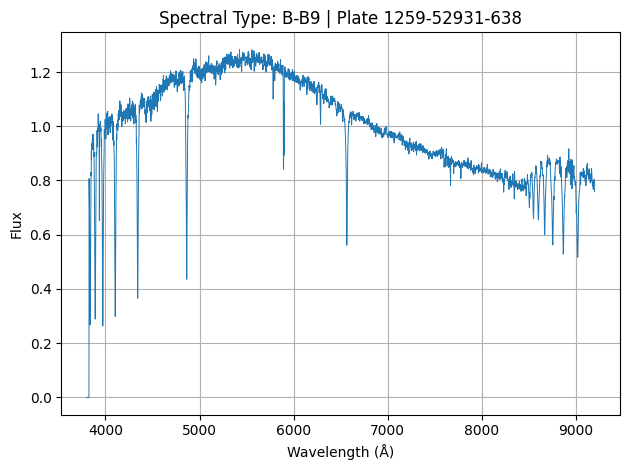

In [18]:
plate, mjd, fiberID = 1259, 52931, 638 #11060, 58523, 493#4050, 55599, 14#3794, 55241, 954#
spectrum, subclass, majorclass = fits_data[(plate, mjd, fiberID)]

print(f"Flux range: min={np.min(spectrum):.3f}, max={np.max(spectrum):.3f}")
plot_spectrum(COMMON_WAVE, spectrum, f"{majorclass}-{subclass}", plate, mjd, fiberID)

## Continuum Normalization Analysis

#### Savitzky-Golay Filtering
Smoothing Filter, keeps general shape (bypasses narrow filters and can oversmooth broad features)  
no external data required, good for good data (high SNR data), not good for noise data    

In [19]:
from scipy.signal import savgol_filter

def continuum_savgol(flux, window=None, poly=3, clip_percentile=90):
    if window is None: window = min(151, len(flux) // 10 | 1) # dynamically find the window based on flux
    if window % 2 == 0: window += 1  # odd window (req by savgol filter)

    # Mask absorption lines (keep only upper X% flux values)
    threshold = np.percentile(flux, clip_percentile)
    mask = flux > threshold
    # Interpolate over masked points for smoother baseline
    interp_flux = np.copy(flux)
    interp_flux[~mask] = np.interp(np.flatnonzero(~mask), np.flatnonzero(mask), flux[mask])

    continuum = savgol_filter(interp_flux, window_length=window, polyorder=poly, mode='interp')
    continuum = np.clip(continuum, 1e-5, None) #Avoid division by very very small numbers so its not inf and ensure its not 0 or -ve
    return flux / continuum, continuum



#### Spline fit
Through a 'pseudo continuum' of high flux points  
adapts to shape of spectrum   
good for moderate and high res, not so good for noise data (peak noises)


In [20]:
from scipy.interpolate import UnivariateSpline

def continuum_spline(wave, flux, high_percentile=95, s_factor=1e-4):
    mask = np.zeros_like(flux, dtype=bool)
    # n_bins = 5
    # bins = np.linspace(wave.min(), wave.max(), n_bins+1)
    n_bins = max(10, len(flux) // 300)
    bins = np.linspace(wave.min(), wave.max(), n_bins + 1)

    for i in range(n_bins):
        bin_mask = (wave >= bins[i]) & (wave < bins[i+1])
        bin_flux = flux[bin_mask]
        if len(bin_flux) == 0:
            continue
        threshold = np.percentile(bin_flux, high_percentile)
        mask[bin_mask] |= (flux[bin_mask] > threshold)

    if np.sum(mask) < 10:
        raise ValueError("Too few points to fit spline")
    
    s = s_factor * (wave.max() - wave.min()) * len(wave)
    spline = UnivariateSpline(wave[mask], flux[mask], s=s)
    continuum = spline(wave)
    continuum = np.clip(continuum, 1e-4, None)
    return flux / continuum, continuum


Uses savgol to smooth out the continuum for removing noise and small features, does a sigma clipping to get continuum points and further separates peaks from troughs

In [21]:
from scipy.interpolate import UnivariateSpline
from scipy.signal import savgol_filter, medfilt

def continuum_spline_wsavgol(wave, flux, smooth_window=None, sigma=2.5, s_factor=1e-4, top_n_per_bin=10, n_bins=15, verbose=False):
    if smooth_window is None: smooth_window = min(151, len(flux) // 10 | 1)
    if smooth_window % 2 == 0: smooth_window += 1

    # Step 1: Initial smoothing
    init_smooth = medfilt(flux, kernel_size=15)
    smoothed = savgol_filter(init_smooth, window_length=smooth_window, polyorder=3)

    # Step 2: Sigma clipping
    mask = np.ones_like(flux, dtype=bool)
    for _ in range(5):
        residual = flux[mask] - smoothed[mask]
        mad = np.median(np.abs(residual - np.median(residual)))
        if mad < 1e-10:
            break
        std = 1.4826 * mad
        mask[mask] = np.abs(residual) < sigma * std
        smoothed = savgol_filter(flux * mask, window_length=smooth_window, polyorder=3)

    # Step 3: Always get points from each bin
    bins = np.linspace(wave.min(), wave.max(), n_bins + 1)
    cont_mask = np.zeros_like(flux, dtype=bool)

    for i in range(n_bins):
        in_bin = (wave >= bins[i]) & (wave < bins[i + 1])
        idx = np.where(in_bin & mask)[0]
        if len(idx) == 0:
            idx = np.where(in_bin)[0]
        if len(idx) > 0:
            top_idx = idx[np.argsort(flux[idx])[-min(top_n_per_bin, len(idx)):]]
            cont_mask[top_idx] = True

    # Step 4: Fit spline to selected points
    wave_scaled = (wave - wave.mean()) / wave.std()
    s = s_factor * len(wave) * np.median(flux)**2
    spline = UnivariateSpline(wave_scaled[cont_mask], flux[cont_mask], s=s)
    continuum = spline(wave_scaled)
    continuum = np.clip(continuum, 1e-5, None)
    norm = flux / continuum
    norm = np.clip(norm, 0, 10)

    if verbose:
        print(f"Spline fit with {np.sum(cont_mask)} points (no fallback). s={s:.2e}")

    return norm, continuum


#### Polynomial Fit
Low degree fit, so, good for low res spectra  
could be underfitting / overfitting

In [22]:
def continuum_polynomial(wave, flux, deg=5, clip_percentile=90):

    wave_scaled = (wave - wave.mean()) / wave.std()

    threshold = np.percentile(flux, clip_percentile)
    mask = flux > threshold

    coeffs = np.polyfit(wave_scaled[mask], flux[mask], deg)
    continuum = np.polyval(coeffs, wave_scaled)
    continuum = np.clip(continuum, 1e-5, None)

    return flux / continuum, continuum



In [23]:
from scipy.signal import medfilt

def continuum_polynomial_weighted(wave, flux, deg=4, high_percentile=90, smooth=True):
    wave_scaled = (wave - wave.mean()) / wave.std()

    if smooth:
        flux_for_weights = medfilt(flux, kernel_size=5)
    else:
        flux_for_weights = flux

    threshold = np.percentile(flux_for_weights, high_percentile)
    weights = np.clip(flux_for_weights / threshold, 0, 1)

    coeffs = np.polyfit(wave_scaled, flux, deg=deg, w=weights)
    continuum = np.polyval(coeffs, wave_scaled)
    continuum = np.clip(continuum, 1e-4, None)

    return flux / continuum, continuum


### Auto

In [24]:
# def score_method(cont):
#     smoothed = savgol_filter(cont, 101, 3)
#     smoothness = np.std(cont - smoothed)
#     flatness = np.abs(np.median(cont - 1.0))
#     return smoothness + 0.5 * flatness  # Weight toward smooth + ~1

def score_method(norm, cont):
    smoothed = savgol_filter(cont, 101, 3)
    smoothness = np.std(cont - smoothed)
    flatness = np.abs(np.median(norm) - 1.0)
    clip_penalty = np.mean((norm > 5) | (norm < 0.2))
    curvature = np.std(np.gradient(cont))
    score = (
        1.0 * smoothness +
        0.5 * flatness +
        2.0 * clip_penalty +
        0.3 * curvature
    )
    return score

def auto_continuum_normalize(wave, flux, verbose=False, methods=None):
    if methods is None:
        methods = [
            "spline_wsavgol",
            "polynomial_weighted",
            "savgol"
        ]

    results = []

    for method in methods:
        try:
            if method == "spline_wsavgol":
                norm, cont = continuum_spline_wsavgol(wave, flux)
            elif method == "polynomial_weighted":
                norm, cont = continuum_polynomial_weighted(wave, flux)
            elif method == "savgol":
                cont = savgol_filter(flux, window_length=151, polyorder=3, mode='interp')
                cont = np.clip(cont, 1e-5, None)
                norm = flux / cont
            else:
                continue  # Unknown method

            results.append((method, norm, cont))
            if verbose:
                print(f"{method} succeeded")

        except Exception as e:
            if verbose:
                print(f"{method} failed: {e}")

    if not results:
        raise RuntimeError("All continuum normalization methods failed.")

    

    scored = [(method, norm, cont, score_method(norm, cont)) for method, norm, cont in results]
    best_method, best_norm, best_cont, best_score = min(scored, key=lambda x: x[3])

    if verbose:
        print("Tried methods (with scores):")
        for method, _, _, score in scored:
            print(f" - {method}: {score:.4f}")
        print(f"Selected '{best_method}' with score {best_score:.4f}")

    return best_norm, best_cont, best_method


### Evaluate

Spline fit with 150 points (no fallback). s=3.60e-01
spline_wsavgol succeeded
polynomial_weighted succeeded
savgol succeeded
Tried methods (with scores):
 - spline_wsavgol: 0.1238
 - polynomial_weighted: 0.1962
 - savgol: 0.0079
Selected 'savgol' with score 0.0079


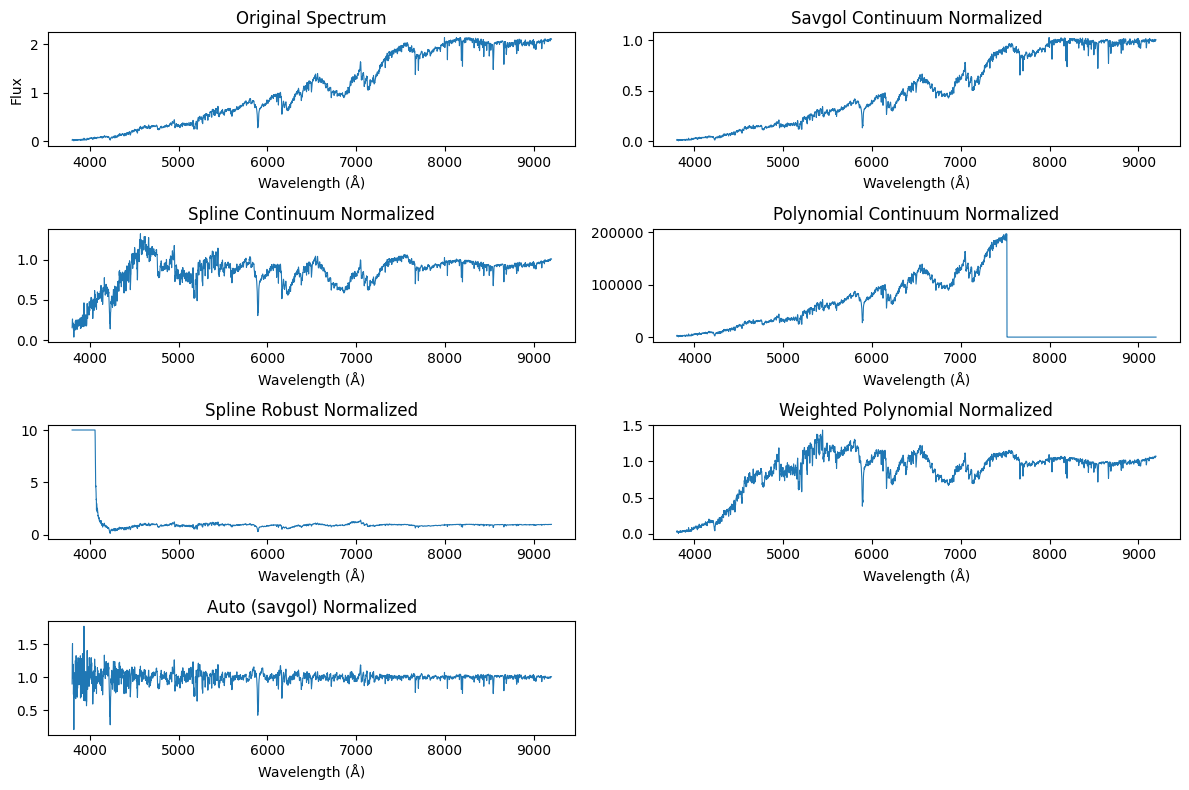

In [25]:
#11060, 58523, 493#4050, 55599, 14#3794, 55241, 954#1259, 52931, 638
spectrum, subclass, majorclass = fits_data[(11060, 58523, 493)]

flux_savgol, cont_savgol = continuum_savgol(spectrum)
flux_spline, cont_spline = continuum_spline(COMMON_WAVE, spectrum)
flux_poly, cont_poly = continuum_polynomial(COMMON_WAVE, spectrum)

flux_spline_wsavgol, cont_spline_wsavgol = continuum_spline_wsavgol(COMMON_WAVE, spectrum, verbose=True)
flux_poly_weighted, cont_poly_weighted = continuum_polynomial_weighted(COMMON_WAVE, spectrum)

flux_auto, cont_auto, method_used = auto_continuum_normalize(COMMON_WAVE, spectrum, verbose=True)


plt.figure(figsize=(12, 8))

plt.subplot(4, 2, 1)
plt.plot(COMMON_WAVE, spectrum, label='Original', lw=0.8)
plt.title("Original Spectrum")
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")

plt.subplot(4, 2, 2)
plt.plot(COMMON_WAVE, flux_savgol, label='Savgol Filter', lw=0.8)
plt.title("Savgol Continuum Normalized")
plt.xlabel("Wavelength (Å)")

plt.subplot(4, 2, 3)
plt.plot(COMMON_WAVE, flux_spline, label='Spline Fit', lw=0.8)
plt.title("Spline Continuum Normalized")
plt.xlabel("Wavelength (Å)")

plt.subplot(4, 2, 4)
plt.plot(COMMON_WAVE, flux_poly, label='Polynomial Fit', lw=0.8)
plt.title("Polynomial Continuum Normalized")
plt.xlabel("Wavelength (Å)")

plt.subplot(4, 2, 5)
plt.plot(COMMON_WAVE, flux_spline_wsavgol, label=f'Spline Robust fit', lw=0.8)
# plt.plot(COMMON_WAVE, spectrum, label="Original")
# plt.plot(COMMON_WAVE, cont_spline_wsavgol, label="Continuum")
# plt.plot(COMMON_WAVE, flux_spline_wsavgol, label="Normalized", alpha=0.7)
plt.title(f"Spline Robust Normalized")
plt.xlabel("Wavelength (Å)")

plt.subplot(4, 2, 6)
plt.plot(COMMON_WAVE, flux_poly_weighted, label=f'Weighted Polynomial fit', lw=0.8)
plt.title(f"Weighted Polynomial Normalized")
plt.xlabel("Wavelength (Å)")

plt.subplot(4, 2, 7)
plt.plot(COMMON_WAVE, flux_auto, label=f'Auto ({method_used}) fit', lw=0.8)
plt.title(f"Auto ({method_used}) Normalized")
plt.xlabel("Wavelength (Å)")

plt.tight_layout()
plt.show()

## Manually Inspect Star spectrum

In [26]:
from scipy.optimize import curve_fit
from scipy.constants import c

In [27]:
#11060, 58523, 493#4050, 55599, 14#3794, 55241, 954#1259, 52931, 638
plate, mjd, fiberID = 4050, 55599, 14
spectrum, subclass, majorclass = fits_data[(plate, mjd, fiberID)]
row = df[(df['plate'] == plate) & (df['mjd'] == mjd) & (df['fiberID'] == fiberID)].iloc[0]
z = row['redshift']

flux_norm, continuum, method_used = auto_continuum_normalize(COMMON_WAVE, spectrum, verbose=True)

spline_wsavgol succeeded
polynomial_weighted succeeded
savgol succeeded
Tried methods (with scores):
 - spline_wsavgol: 0.0046
 - polynomial_weighted: 0.0543
 - savgol: 0.0151
Selected 'spline_wsavgol' with score 0.0046


In [28]:
def plot_overview(tag, common_wave, spectrum, flux_norm, method_used, save_path=None):
    plt.figure(figsize=(12, 3))
    plt.subplot(1, 2, 1)
    plt.plot(common_wave, spectrum, lw=0.8)
    plt.title(f"Original Spectrum {tag}")
    plt.subplot(1, 2, 2)
    plt.plot(common_wave, flux_norm, lw=0.8)
    plt.title(f"Normalized ({method_used})")
    plt.tight_layout()
    if save_path: plt.savefig(save_path)
    else: plt.show()
    plt.close()

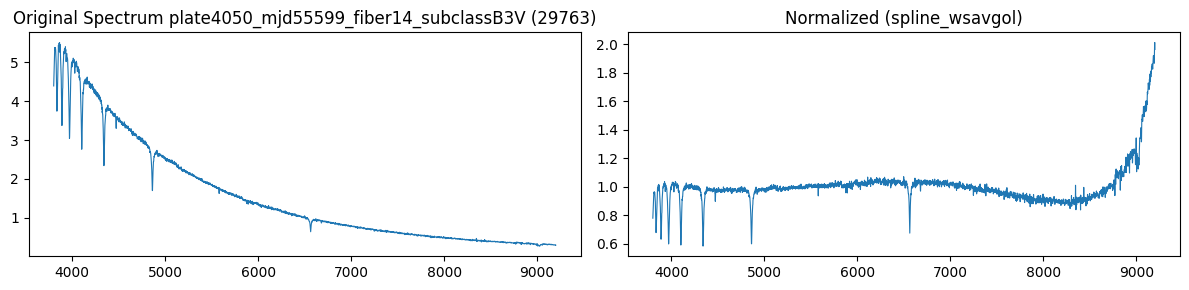

In [29]:
tag = f"plate{plate}_mjd{mjd}_fiber{fiberID}_subclass{subclass}"
plot_overview(tag, COMMON_WAVE, spectrum, flux_norm, method_used)

In [30]:
spectral_lines_master = { #TODO: Verify https://physics.nist.gov/PhysRefData/ASD/lines_form.html and improve
    'Hα': 6563,
    'Hβ': 4861,
    'Hγ': 4340,
    'Hδ': 4102,
    'Ca II K': 3933,
    'Ca II H': 3968,
    'Ca I': 4226,
    'Ca II IR1': 8498,
    'Ca II IR2': 8542,
    'Ca II IR3': 8662,
    'Na I D1': 5890,
    'Na I D2': 5896,
    'Mg I': 5170,
    'Mg II': 4481,
    'Fe I': 4385,
    'Fe II': 4520,
    'He I': 4471,
    'He II': 4686,
    'TiO Band 1': 4760,
    'TiO Band 2': 4950,
    'TiO Band 3': 6150,
    'TiO Band 4': 7050,
    'TiO Band 5': 7600,
    'VO Band': 7900
}


In [31]:
def gaussian_abs(x, amp, cen, sigma):
    return 1 - amp * np.exp(-(x - cen)**2 / (2 * sigma**2))

def estimate_local_sn(flux):
    med = np.median(flux)
    mad = np.median(np.abs(flux - med))
    return med / (1.4826 * mad + 1e-6)

def fit_spectral_line(wave, flux, line_center, redshift=0.0, window_A=5.0):
    obs_center = line_center * (1 + redshift)
    idx_center = np.argmin(np.abs(wave - obs_center))
    dw = np.mean(np.diff(wave))
    half_window = int(window_A / dw)
    i1, i2 = max(0, idx_center - half_window), min(len(wave), idx_center + half_window)

    x = wave[i1:i2]
    y = flux[i1:i2]
    if len(x) < 5:
        return None

    amp_guess = max(0.01, 1 - np.min(y))
    try:
        popt, pcov = curve_fit(
            gaussian_abs, x, y,
            p0=[amp_guess, obs_center, 1.0],
            bounds=([0, obs_center - 2, 0.1], [1, obs_center + 2, 10]),
            maxfev=5000
        )
        amp, cen, sigma = popt
        perr = np.sqrt(np.diag(pcov))
    except Exception:
        return None

    sn = estimate_local_sn(y)
    EW = np.trapz(1 - gaussian_abs(x, *popt), x)
    chi2 = np.mean(((y - gaussian_abs(x, *popt)) / (np.std(y) + 1e-5))**2)

    return {
        'label': None,
        'line_center_rest': line_center,
        'line_center_obs': cen,
        'depth': amp,
        'width_sigma': sigma,
        'eq_width': EW,
        'S/N_local': sn,
        'chi2': chi2,
        'fit_uncertainty': perr.tolist()
    }

def detect_lines_for_spectrum(wave, flux, redshift, line_dict, window_A=8.0, sn_cut=5):
    results = []
    for label, wl_rest in line_dict.items():
        res = fit_spectral_line(wave, flux, wl_rest, redshift, window_A)
        if res and res['depth'] > 0.02 and res['S/N_local'] > sn_cut and res['chi2'] < 5:
            res['label'] = label
            results.append(res)
    return results

In [32]:
detected_lines = detect_lines_for_spectrum(COMMON_WAVE, flux_norm, z, spectral_lines_master)
print(f"Detected {len(detected_lines)} lines:")
for l in detected_lines:
    print(f"  {l['label']}: depth={l['depth']:.2f}, EW={l['eq_width']:.2f}Å, center={l['line_center_obs']:.1f}Å")


Detected 20 lines:
  Hα: depth=0.30, EW=2.75Å, center=6563.1Å
  Hβ: depth=0.38, EW=4.08Å, center=4861.5Å
  Hγ: depth=0.39, EW=4.20Å, center=4340.5Å
  Hδ: depth=0.39, EW=4.32Å, center=4101.9Å
  Ca II K: depth=0.04, EW=0.08Å, center=3934.0Å
  Ca I: depth=0.03, EW=0.02Å, center=4226.8Å
  Ca II IR1: depth=0.08, EW=1.04Å, center=8494.9Å
  Ca II IR2: depth=0.07, EW=0.79Å, center=8537.8Å
  Ca II IR3: depth=0.04, EW=0.49Å, center=8661.4Å
  Na I D1: depth=0.03, EW=0.08Å, center=5890.5Å
  Na I D2: depth=0.04, EW=0.09Å, center=5892.5Å
  Mg II: depth=0.04, EW=0.54Å, center=4477.8Å
  Fe I: depth=0.02, EW=0.26Å, center=4385.9Å
  Fe II: depth=0.03, EW=0.34Å, center=4517.7Å
  He I: depth=0.08, EW=0.65Å, center=4471.6Å
  He II: depth=0.02, EW=0.27Å, center=4682.8Å
  TiO Band 1: depth=0.03, EW=0.22Å, center=4760.8Å
  TiO Band 2: depth=0.02, EW=0.29Å, center=4946.7Å
  TiO Band 5: depth=0.05, EW=0.60Å, center=7596.0Å
  VO Band: depth=0.09, EW=1.15Å, center=7898.2Å


In [33]:
def classify_star_from_lines(detected_lines):
    # Get references to lines or features
    he2 = next((l for l in detected_lines if l['label'] == 'He II'), None)
    he1 = next((l for l in detected_lines if l['label'] == 'He I'), None)
    na_d = any(l['label'] in {'Na I D1', 'Na I D2'} for l in detected_lines)
    tio = any('TiO' in l['label'] for l in detected_lines)
    vo = any('VO' in l['label'] for l in detected_lines)
    h_beta = next((l for l in detected_lines if l['label'] == 'Hβ'), None)

    # Rule-based classification
    if he2 and he2['depth'] > 0.05:
        return "O"
    elif he1 and he1['depth'] > 0.1:
        return "B"
    elif h_beta and h_beta['depth'] > 0.25 and not he1:
        return "A"
    elif na_d and not (tio or vo):
        return "F"
    elif not na_d and not tio and not vo:
        return "G"  # weak metals, fallback between F and K
    elif tio and not vo:
        return "K"
    elif vo:
        return "M"
    else:
        return "Unknown"


In [34]:
classify_star_from_lines(detected_lines)

'M'

In [35]:
def plot_detected_lines(wave,flux,detected_lines,line_dict,zoom=None,title=None,cmap='inferno',figsize=(14, 4),padding=0.05,depth_scale=(0.02, 0.6), save_path=None):

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(wave, flux, lw=0.8, color='black', label="Normalized Flux")

    # Handle zoom region dynamically
    if zoom:
        mask = (wave >= zoom[0]) & (wave <= zoom[1])
        x_min, x_max = zoom
        y_min, y_max = np.min(flux[mask]), np.max(flux[mask])
    else:
        mask = np.ones_like(wave, dtype=bool)
        x_min, x_max = wave.min(), wave.max()
        y_min, y_max = np.min(flux), np.max(flux)

    y_pad = (y_max - y_min) * padding
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    # Map detected lines by rest wavelength
    detected_map = {round(l['line_center_rest'], 1): l for l in detected_lines}

    # Color scale for line depth
    norm = plt.Normalize(*depth_scale)
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])  # Ensure colorbar knows this is a valid mappable

    # Draw all lines
    for label, wl_rest in line_dict.items():
        found = None
        for l in detected_lines:
            if np.isclose(l['line_center_rest'], wl_rest, atol=2):
                found = l
                break

        if found:
            depth = found['depth']
            color = sm.to_rgba(depth)
            alpha = 0.9
            linestyle = '-'
            obs_wl = found['line_center_obs']
        else:
            color = 'gray'
            alpha = 0.7
            linestyle = '--'
            obs_wl = wl_rest

        if zoom and not (zoom[0] <= obs_wl <= zoom[1]):
            continue

        ax.axvline(obs_wl, color=color, lw=1.0, ls=linestyle, alpha=alpha)
        ax.text(obs_wl,y_max + y_pad * 0.15,label,rotation=90,fontsize=12,color=color,va='bottom',ha='center',alpha=alpha)

    ax.set_title(title or "Spectral Line Map (Detected vs Expected)", fontsize=12)
    ax.set_xlabel("Wavelength (Å)")
    ax.set_ylabel("Normalized Flux")
    ax.grid(True, alpha=0.3)

    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label("Line Depth (Detection Strength)")

    plt.tight_layout()
    if save_path: plt.savefig(save_path)
    else: plt.show()
    plt.close()


Plate 4050, MJD 55599, Fiber 14, subclass B3V (29763)


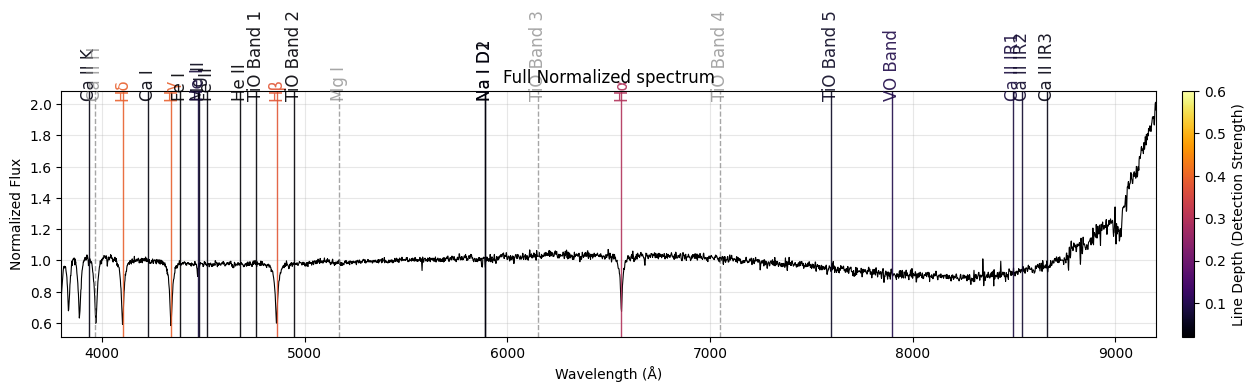

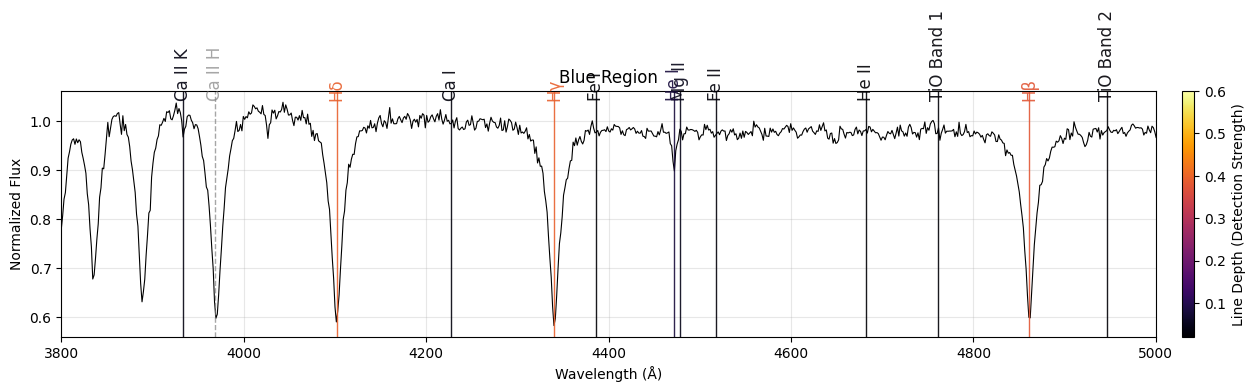

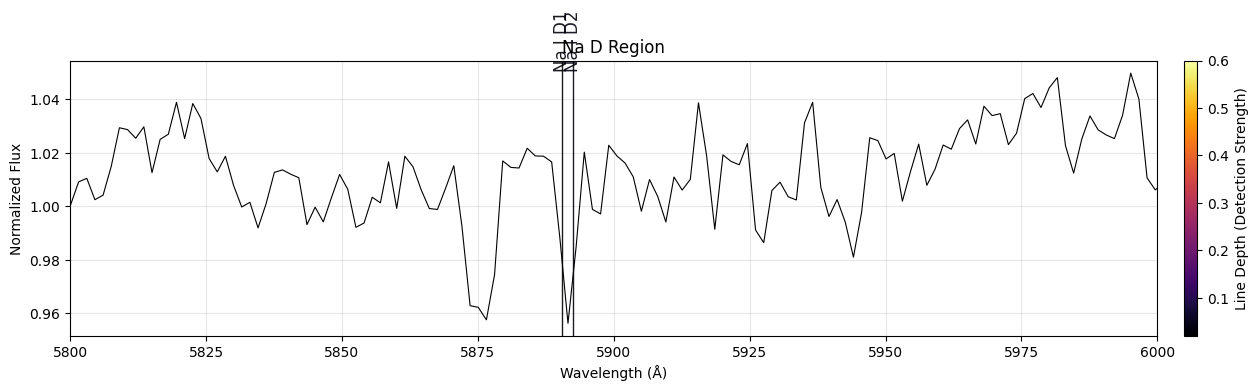

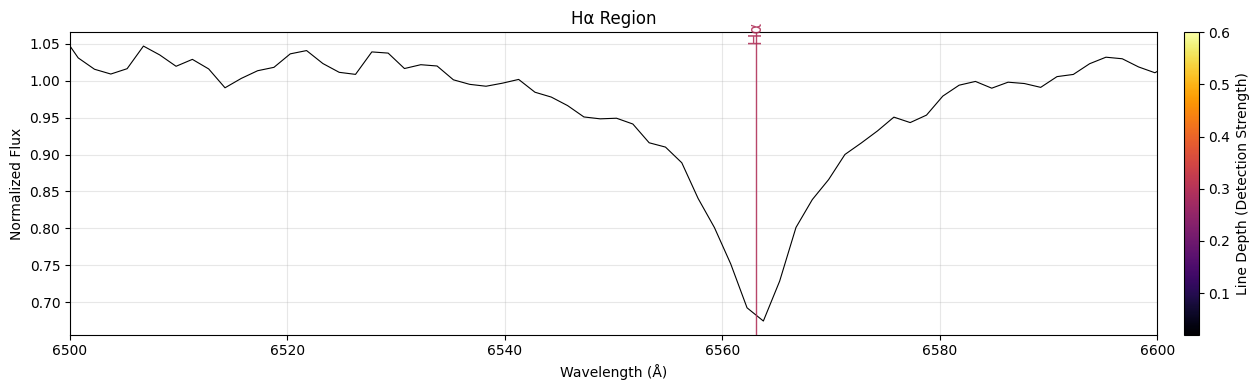

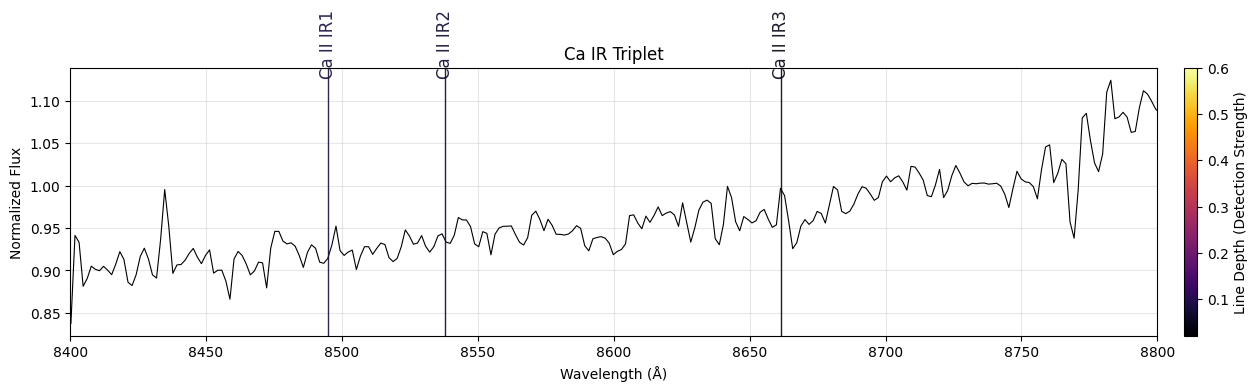

In [36]:
print(f"Plate {plate}, MJD {mjd}, Fiber {fiberID}, subclass {subclass}")
plot_detected_lines(COMMON_WAVE,flux_norm,detected_lines,spectral_lines_master,title=f"Full Normalized spectrum")

regions = {
    "Blue Region": (3800, 5000),
    "Na D Region": (5800, 6000),
    "Hα Region": (6500, 6600),
    "Ca IR Triplet": (8400, 8800)
}

for name, zoom in regions.items():
    plot_detected_lines(COMMON_WAVE,flux_norm,detected_lines,spectral_lines_master,zoom=zoom,title=name)


### Iterate
Run for all data and save 

In [37]:
def process_star(plate, mjd, fiberID, spectrum, row, z, save_dir=f"{data_output_dir}/manual_class"):
    # Normalize
    flux_norm, continuum, method_used = auto_continuum_normalize(COMMON_WAVE, spectrum)
    
    # Detect lines
    detected_lines = detect_lines_for_spectrum(COMMON_WAVE, flux_norm, z, spectral_lines_master)

    # Predict class
    pred_class = classify_star_from_lines(detected_lines)

    # Save plots
    tag = re.sub(r'[^\w\-_.]', '_', str(f"plate{plate}_mjd{mjd}_fiber{fiberID}_subclass{subclass}"))
    # plot_overview(tag, COMMON_WAVE, spectrum, flux_norm, method_used, save_path=f"{save_dir}/{tag}_overview.png")
    # plot_detected_lines(COMMON_WAVE, flux_norm, detected_lines, spectral_lines_master, title="Full Normalized spectrum", figsize=(12, 3), save_path=f"{save_dir}/{tag}_lines_full.png")

    # for region_name, zoom in {
    #     "Blue": (3800, 5000),
    #     "NaD": (5800, 6000),
    #     "Halpha": (6500, 6600),
    #     "CaIR": (8400, 8800)
    # }.items():
    #     plot_detected_lines(COMMON_WAVE, flux_norm, detected_lines, spectral_lines_master,
    #                         zoom=zoom, title=region_name, save_path=f"{save_dir}/{tag}_lines_{region_name}.png")

    # Store result
    summary = {
        "plate": plate,
        "mjd": mjd,
        "fiberID": fiberID,
        "z": z,
        "SDSS_class": subclass,
        "SDSS_major": majorclass,
        "pred_class": pred_class,
        "num_lines": len(detected_lines),
        "method": method_used,
    }

    # Flatten detected line info
    for line in detected_lines:
        line_tag = f"{line['label'].replace(' ', '_')}"
        summary[f"{line_tag}_EW"] = line['eq_width']
        summary[f"{line_tag}_depth"] = line['depth']

    return summary

In [38]:
results = []
for (plate, mjd, fiberID), (spectrum, subclass, majorclass) in fits_data.items():
    spectrum, subclass, majorclass = fits_data[(plate, mjd, fiberID)]
    row = df[(df['plate'] == plate) & (df['mjd'] == mjd) & (df['fiberID'] == fiberID)].iloc[0]
    z = row['redshift']
    res = process_star(plate, mjd, fiberID, spectrum, row, z)
    results.append(res)

# Save results to CSV
pd.DataFrame(results).to_csv(f"{data_output_dir}/manual_class/star_classification_results2.csv", index=False)

In [4]:
manual_class_results = pd.read_csv(f"{data_output_dir}/manual_class/star_classification_results.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data_output/starspectra/manual_class/star_classification_results.csv'

# Prepare Train-test set

In [19]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from collections import Counter
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

### Create Features and labels

In [20]:
X, y, idx = [], [], []

for (plate, mjd, fiberID), (spectrum, subclass, majorclass) in fits_data.items():
    X.append(spectrum)
    y.append(majorclass)
    idx.append((plate, mjd, fiberID))

X = np.array(X)
y = np.array(y)

In [21]:
print(f"Total samples: {len(X)}, {len(y)}")

Total samples: 3191, 3191


### Normalize

In [22]:
X_norm = []

for flux in X:
    continuum = continuum_savgol(flux)
    continuum = np.clip(continuum, 1e-5, None)
    norm_flux = flux / continuum
    norm_flux = (norm_flux - np.mean(norm_flux)) / np.std(norm_flux)
    X_norm.append(norm_flux)

X_norm = np.array(X_norm)


#### Inspect

In [23]:
def compute_flux_stats(spectra):
    stats = {
        'min_flux': np.min(spectra, axis=1),
        'max_flux': np.max(spectra, axis=1),
        'mean_flux': np.mean(spectra, axis=1),
        'median_flux': np.median(spectra, axis=1),
        'range_flux': np.ptp(spectra, axis=1),  # max - min
    }
    return pd.DataFrame(stats)

flux_stats_df = compute_flux_stats(X)
flux_stats_df_norm = compute_flux_stats(X_norm)

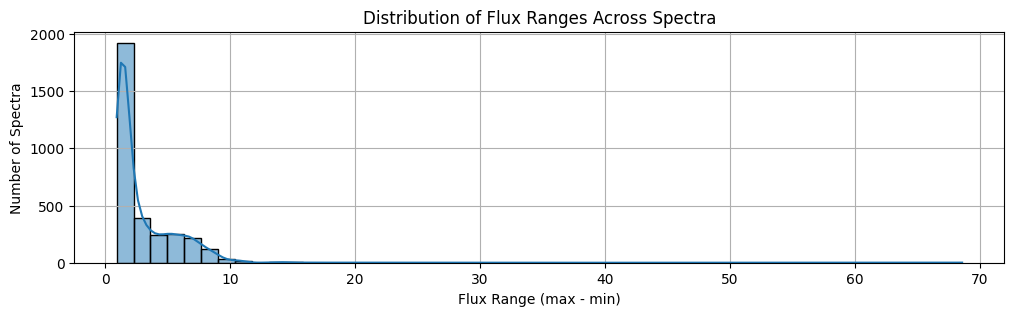

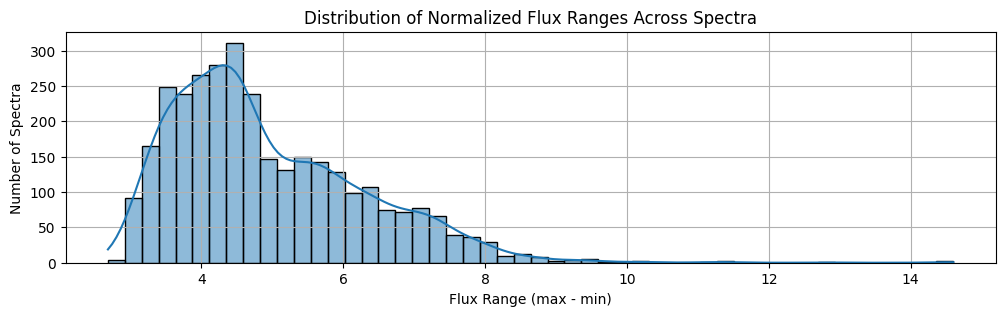

In [24]:
plt.figure(figsize=(12, 3))
sns.histplot(flux_stats_df['range_flux'], bins=50, kde=True)
plt.title("Distribution of Flux Ranges Across Spectra")
plt.xlabel("Flux Range (max - min)")
plt.ylabel("Number of Spectra")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 3))
sns.histplot(flux_stats_df_norm['range_flux'], bins=50, kde=True)
plt.title("Distribution of Normalized Flux Ranges Across Spectra")
plt.xlabel("Flux Range (max - min)")
plt.ylabel("Number of Spectra")
plt.grid(True)
plt.show()

### balance

In [25]:
class_counts = Counter(y)
print("Original class counts:")
for label, count in class_counts.items():
    print(f"{label}: {count}")

Original class counts:
B: 463
M: 439
F: 484
O: 493
G: 448
A: 405
K: 459


#### Separate rare classes

In [67]:
valid_classes = [cls for cls, count in class_counts.items() if count >= 10]
rare_classes = [cls for cls in class_counts if cls not in valid_classes]

mask_valid = np.isin(y, valid_classes)
mask_rare = np.isin(y, rare_classes)

X_valid, y_valid = X_norm[mask_valid], y[mask_valid]
X_rare, y_rare = X_norm[mask_rare], y[mask_rare]
idx_valid = np.array(idx)[mask_valid]

In [27]:
rare_classes

[]

#### Oversampling / SMOTE if required

##### Oversampling

In [28]:
# X_rare_aug, y_rare_aug = [], []

# for cls in np.unique(y_rare):
#     X_cls = X_rare[y_rare == cls]
#     n_samples = 10  
#     X_resampled = resample(X_cls, replace=True, n_samples=n_samples, random_state=42)
#     X_rare_aug.append(X_resampled)
#     y_rare_aug += [cls] * n_samples

# if X_rare_aug:
#     X_oversampled = np.vstack([X] + X_rare_aug)
#     y_oversampled = np.hstack([y] + [y_rare_aug])

In [29]:
# print("Original    class counts:", Counter(y))
# print("Oversampled class counts:", Counter(y_oversampled))

##### SMOTE

In [30]:
# smote = SMOTE(sampling_strategy='auto', random_state=42)
# X_rare_smote, y_rare_smote = smote.fit_resample(X_rare, y_rare)

# X_SMOTE = np.vstack([X, X_rare_smote])
# y_SMOTE = np.hstack([y, y_rare_smote])

In [31]:
# print("Original class counts:", Counter(y))
# print("SMOTE    class counts:", Counter(y_SMOTE))

### Split

In [68]:
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_valid, y_valid, idx_valid, test_size=0.2, stratify=y_valid, random_state=42
)

# NOTE - Adding oversampled data in test/val is a data leak - we should split before oversampling! (and even before smote if you can - i.e. if you have enough data otherwise just be aware your test metrics wouldn't mean much and overfitting will still be quite possible with validation set) 

# X_train, X_test, y_train, y_test = train_test_split(
#     X_smote, y_smote, test_size=0.2, stratify=y_smote, random_state=42
# )

In [69]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train class counts:", Counter(y_train))
print("Test class counts:", Counter(y_test))

Train shape: (2552, 3600)
Test shape: (639, 3600)
Train class counts: Counter({'O': 394, 'F': 387, 'B': 370, 'K': 367, 'G': 359, 'M': 351, 'A': 324})
Test class counts: Counter({'O': 99, 'F': 97, 'B': 93, 'K': 92, 'G': 89, 'M': 88, 'A': 81})


### Encode Labels

In [70]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train class counts:", Counter(y_train))
print("Test class counts:", Counter(y_test))

Train shape: (2552, 3600)
Test shape: (639, 3600)
Train class counts: Counter({'O': 394, 'F': 387, 'B': 370, 'K': 367, 'G': 359, 'M': 351, 'A': 324})
Test class counts: Counter({'O': 99, 'F': 97, 'B': 93, 'K': 92, 'G': 89, 'M': 88, 'A': 81})


In [71]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
print("Train class counts:", Counter(y_train_enc))
print("Test class counts:", Counter(y_test_enc))

Train class counts: Counter({6: 394, 2: 387, 1: 370, 4: 367, 3: 359, 5: 351, 0: 324})
Test class counts: Counter({6: 99, 2: 97, 1: 93, 4: 92, 3: 89, 5: 88, 0: 81})


# Test Run - Rough Baseline

## RF

In [72]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [73]:
clf = RandomForestClassifier(n_estimators=100, random_state=0)
clf.fit(X_train, y_train_enc)

RandomForestClassifier(random_state=0)

In [74]:
y_pred = clf.predict(X_test)

              precision    recall  f1-score   support

           A       0.90      0.93      0.91        81
           B       0.96      0.83      0.89        93
           F       0.76      0.84      0.80        97
           G       0.85      0.87      0.86        89
           K       0.96      0.92      0.94        92
           M       0.98      0.98      0.98        88
           O       0.93      0.96      0.95        99

    accuracy                           0.90       639
   macro avg       0.91      0.90      0.90       639
weighted avg       0.90      0.90      0.90       639



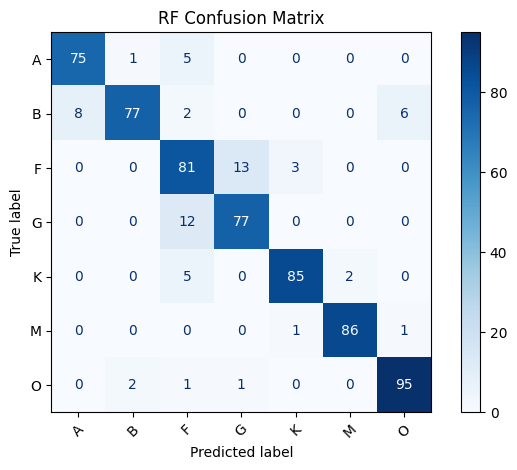

In [75]:
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))
# print(confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test_enc, y_pred)
labels = le.classes_
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("RF Confusion Matrix")
plt.grid(False)
plt.tight_layout()
plt.show()

In [76]:
joblib.dump(clf, f'{data_output_dir}/models/random_forest_model.joblib')

['../data_output/starspectra/models/random_forest_model.joblib']

# Define Model

In [77]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

In [78]:
num_classes = len(np.unique(y_train_enc))
n_bins = X_train.shape[1] 
print(f"{num_classes} , {n_bins}")

7 , 3600


In [79]:
X_train_cnn = X_train[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]

In [80]:
X_train_cnn.shape

(2552, 3600, 1)

In [81]:
# X_train_cnn[0]

In [82]:
# y_train_enc

In [83]:
model = Sequential([
    layers.Input(shape=(n_bins, 1)),

    layers.Conv1D(32, kernel_size=7, activation='relu', padding='same'),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.2),

    layers.Conv1D(64, kernel_size=5, activation='relu', padding='same'),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.2),

    layers.Conv1D(128, kernel_size=5, activation='relu', padding='same'),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.3),

    layers.Flatten(),
    
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(num_classes, activation='softmax')
])

In [84]:
log_dir = os.path.join(f"{data_output_dir}/logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_cb = TensorBoard(log_dir=log_dir, histogram_freq=1)
early_stop_cb = EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr_cb = ReduceLROnPlateau(factor=0.5, patience=3)
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(f"{data_output_dir}/models/best_model.keras", save_best_only=True)


In [85]:
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

In [86]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 3600, 32)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 1800, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1800, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 1800, 64)       │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 900, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 900, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 900, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 450, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 450, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,425,479 (28.33 MB)

 Trainable params: 7,425,479 (28.33 MB)

 Non-trainable params: 0 (0.00 B)

# Train

In [87]:
history = model.fit(
    X_train_cnn, y_train_enc,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    # validation_data=(X_val_cnn, y_val_enc),
    callbacks=[tensorboard_cb, early_stop_cb, reduce_lr_cb, checkpoint_cb]
)

Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - loss: 1.1887 - sparse_categorical_accuracy: 0.5309 - val_loss: 0.7833 - val_sparse_categorical_accuracy: 0.7025 - learning_rate: 1.0000e-04
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - loss: 0.7810 - sparse_categorical_accuracy: 0.6579 - val_loss: 0.6821 - val_sparse_categorical_accuracy: 0.7182 - learning_rate: 1.0000e-04
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - loss: 0.7443 - sparse_categorical_accuracy: 0.6738 - val_loss: 0.6350 - val_sparse_categorical_accuracy: 0.7652 - learning_rate: 1.0000e-04
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - loss: 0.6711 - sparse_categorical_accuracy: 0.7058 - val_loss: 0.5845 - val_sparse_categorical_accuracy: 0.7534 - learning_rate: 1.0000e-04
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - loss: 0.6515 - sparse_categorical_accuracy: 0.7280 - val_loss: 0.5498 - val_sparse_categorical_accuracy: 0.7945 - learning_rate: 1.0000e-04
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 

In [88]:
# To see training Progress run this on CLI
# tensorboard --logdir=data_output/starspectra/logs/
# http://localhost:6006

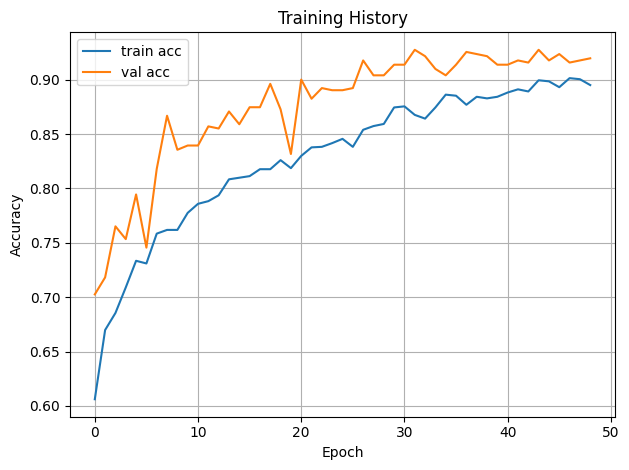

In [97]:
plt.figure()
plt.plot(history.history['sparse_categorical_accuracy'], label='train acc')
plt.plot(history.history['val_sparse_categorical_accuracy'], label='val acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training History")
plt.grid(True)
plt.tight_layout()
plt.show()

# Evaluate

In [90]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import label_binarize

### Predict

In [98]:
y_pred_probs = model.predict(X_test_cnn)
y_pred = np.argmax(y_pred_probs, axis=1)

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 240ms/step


### Classification Report

In [99]:
print("Classification Report:\n")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

Classification Report:

              precision    recall  f1-score   support

           A       0.89      0.96      0.92        81
           B       0.96      0.83      0.89        93
           F       0.85      0.78      0.82        97
           G       0.83      0.91      0.87        89
           K       0.96      0.93      0.95        92
           M       0.98      0.98      0.98        88
           O       0.92      0.99      0.96        99

    accuracy                           0.91       639
   macro avg       0.91      0.91      0.91       639
weighted avg       0.91      0.91      0.91       639



### Confusion Matrix

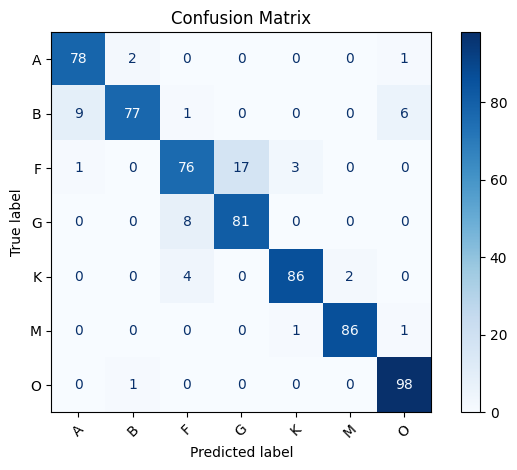

In [100]:
cm = confusion_matrix(y_test_enc, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

### ROC

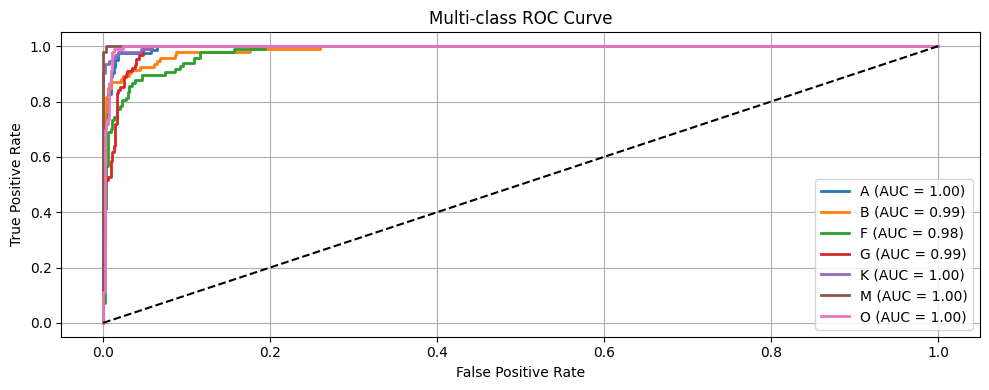

In [101]:
# y_pred_probs = model.predict(X_test_cnn) 
class_names = le.classes_

y_bin = label_binarize(y_test_enc, classes=np.arange(len(class_names)))  # shape: (n_samples, n_classes)

fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(10, 4))
for i in range(len(class_names)):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2, label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


### Misclassified Analysis

In [104]:
def plot_misclassified(spectrum, norm_flux, true_label, predicted_label):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(COMMON_WAVE, spectrum, lw=0.8)
    plt.title(f"Original Spectrum\nTrue: {true_label}, Pred: {predicted_label}")
    plt.xlabel("Wavelength (Å)")
    plt.ylabel("Flux")
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(COMMON_WAVE, norm_flux, lw=0.8)
    plt.title("Normalized Spectrum (Savgol)")
    plt.xlabel("Wavelength (Å)")
    plt.ylabel("Normalized Flux")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{data_output_dir}/plots/misclassified/{true_label}_{predicted_label}")
    plt.close()
    # plt.show()

In [109]:
misclassified_indices_y = np.where(y_pred != y_test_enc)[0]
misclassified_keys = []

for i in misclassified_indices_y:
    true_label = le.inverse_transform([y_test_enc[i]])[0]
    pred_label = le.inverse_transform([y_pred[i]])[0]

    plate, mjd, fiberID = idx_test[i]
    misclassified_keys.append(idx_test[i])
    spectrum, _, _ = fits_data[(plate, mjd, fiberID)]

    X_normalized_data = X_test[i]
    X_original_data = spectrum

    plot_misclassified(X_original_data, X_normalized_data, true_label, pred_label)

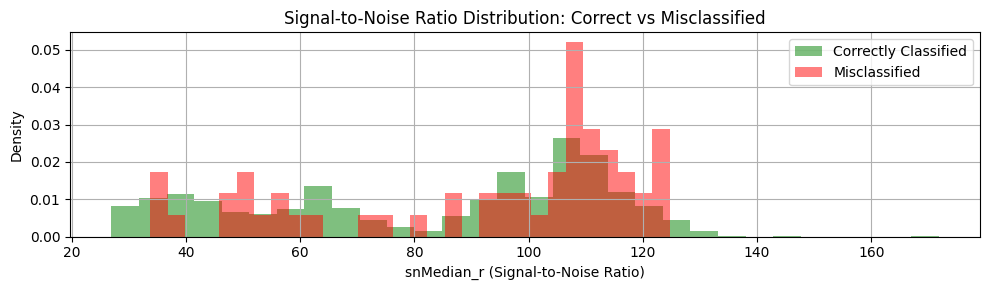

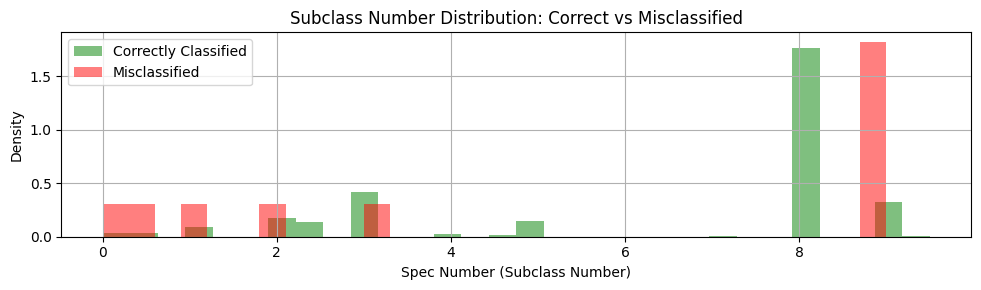

{'Mean snMedian_r': {'Correct': 82.800639645933,
  'Misclassified': 92.22131280701755},
 'Mean spec_number': {'Correct': 6.339622641509434, 'Misclassified': 5.5}}

In [ ]:
# df['key'] = list(zip(df['plate'], df['mjd'], df['fiberID']))
df['plate'] = df['plate'].astype(int)
df['mjd'] = df['mjd'].astype(int)
df['fiberID'] = df['fiberID'].astype(int)
df['key'] = list(zip(df['plate'], df['mjd'], df['fiberID']))
misclassified_keys = [tuple(map(int, key)) for key in misclassified_keys]

misclassified_df = df[df['key'].isin(misclassified_keys)]
correct_df = df[~df['key'].isin(misclassified_keys)]

# Plot snMedian_r
plt.figure(figsize=(10, 3))
plt.hist(correct_df['snMedian_r'], bins=30, alpha=0.5, label='Correctly Classified', color='green', density=True)
plt.hist(misclassified_df['snMedian_r'], bins=30, alpha=0.5, label='Misclassified', color='red', density=True)
plt.xlabel('snMedian_r (Signal-to-Noise Ratio)')
plt.ylabel('Density')
plt.title('Signal-to-Noise Ratio Distribution: Correct vs Misclassified')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot spec_number
plt.figure(figsize=(10, 3))
plt.hist(correct_df['spec_number'].dropna(), bins=30, alpha=0.5, label='Correctly Classified', color='green', density=True)
plt.hist(misclassified_df['spec_number'].dropna(), bins=30, alpha=0.5, label='Misclassified', color='red', density=True)
plt.xlabel('Spec Number (Subclass Number)')
plt.ylabel('Density')
plt.title('Subclass Number Distribution: Correct vs Misclassified')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



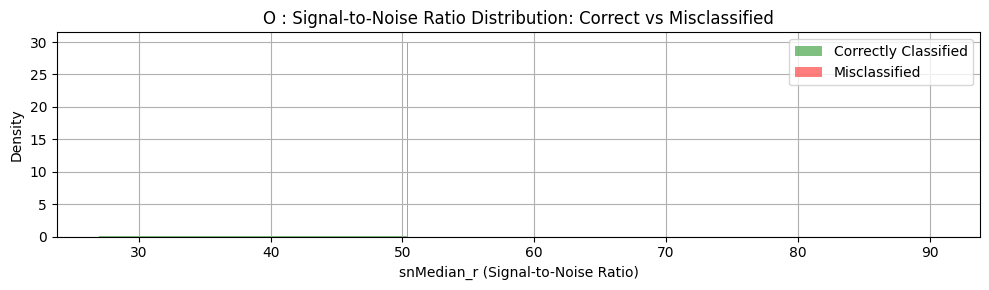

c:\Users\aquaf\anaconda3\envs\astro_sandbox\lib\site-packages\numpy\lib\histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


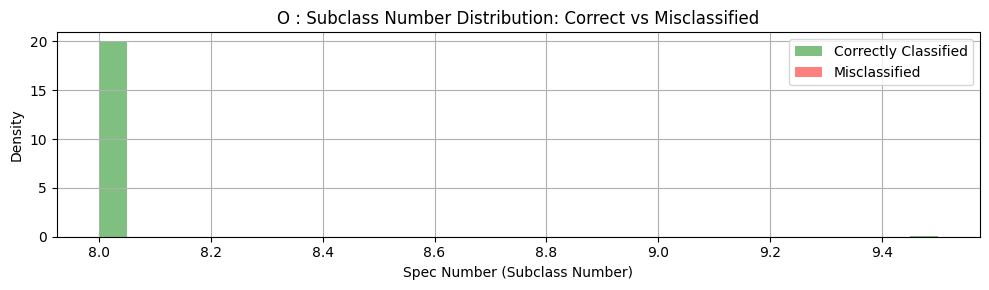

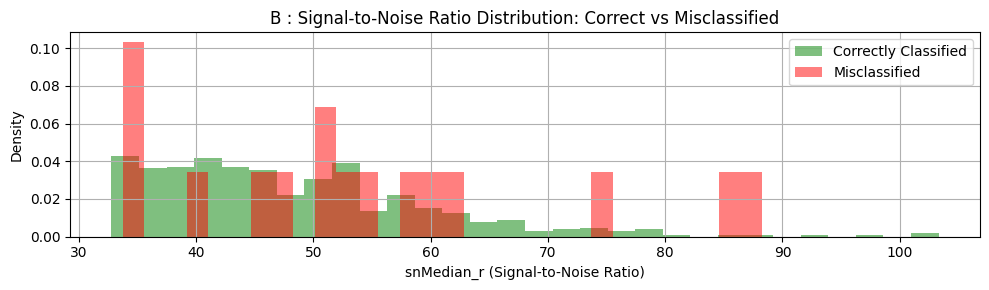

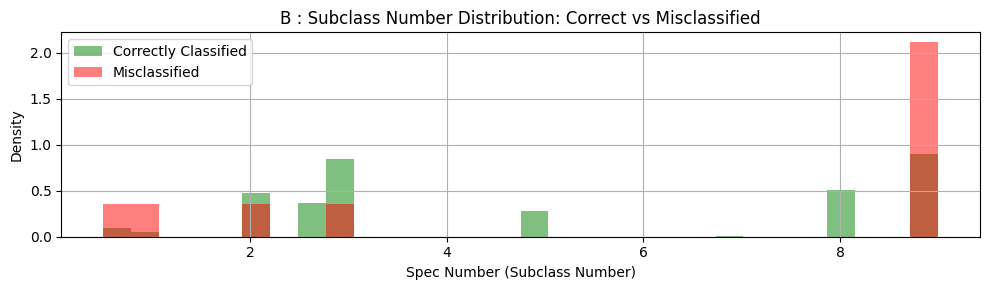

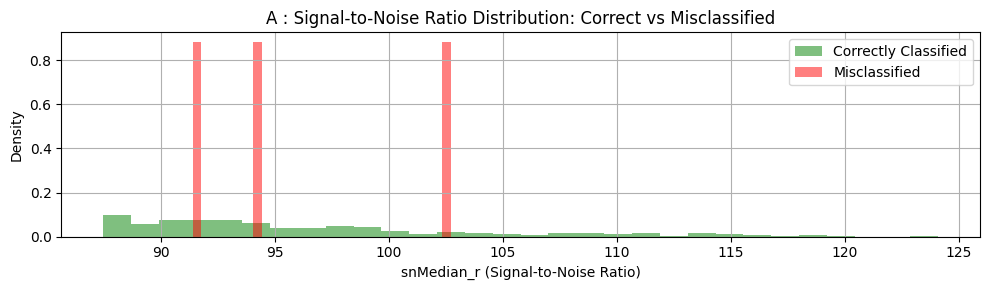

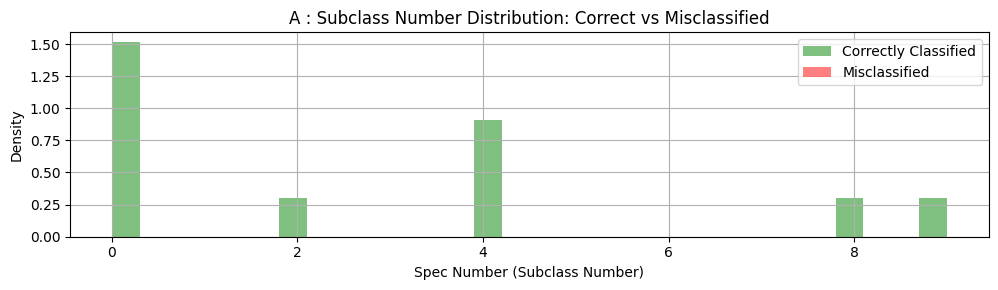

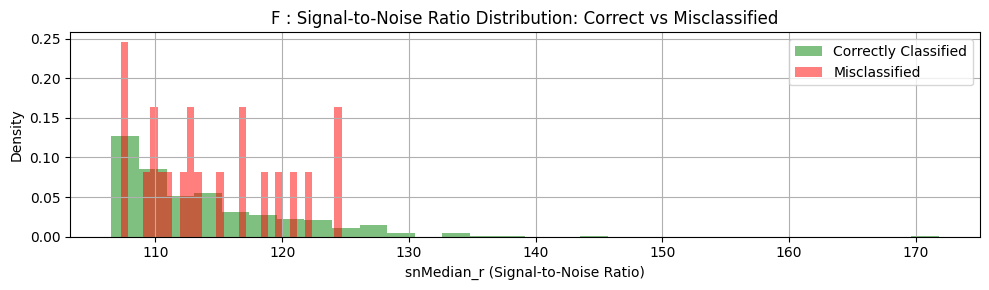

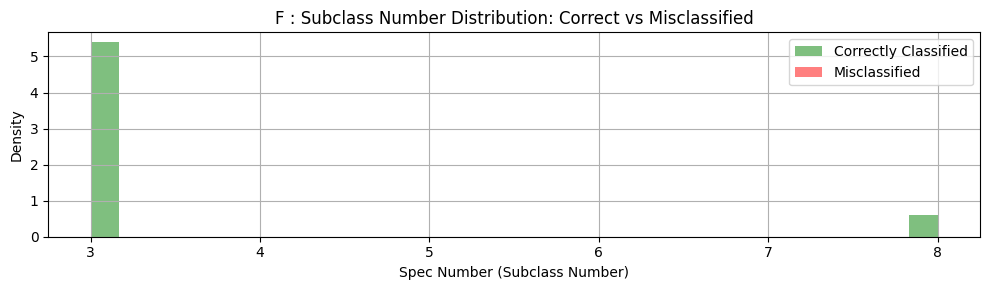

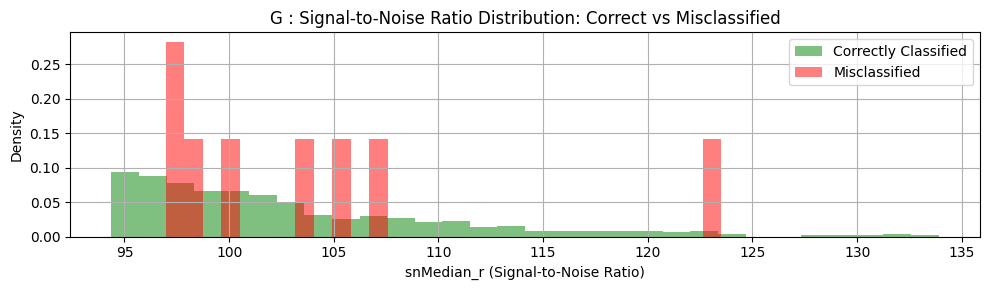

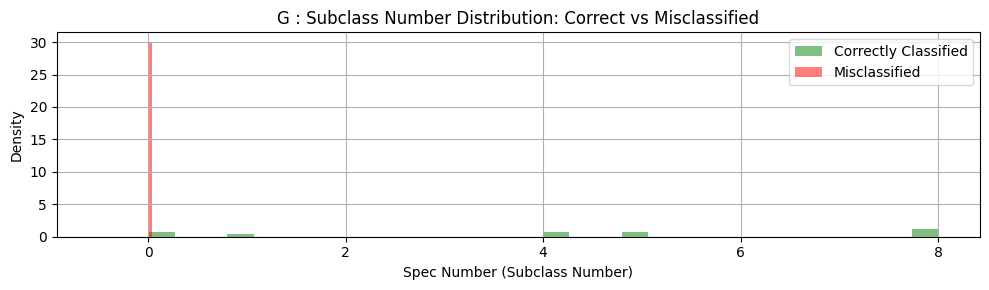

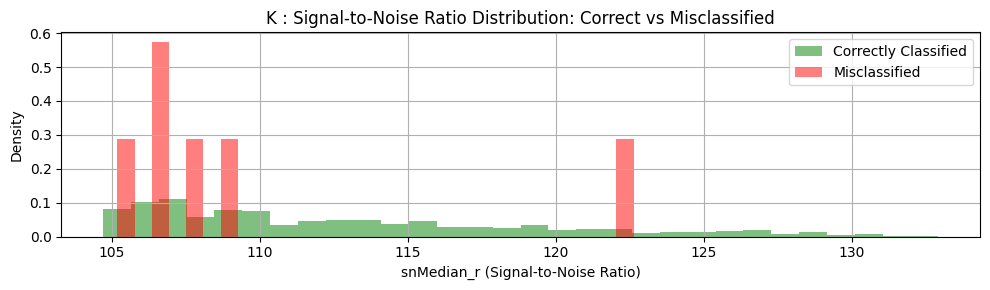

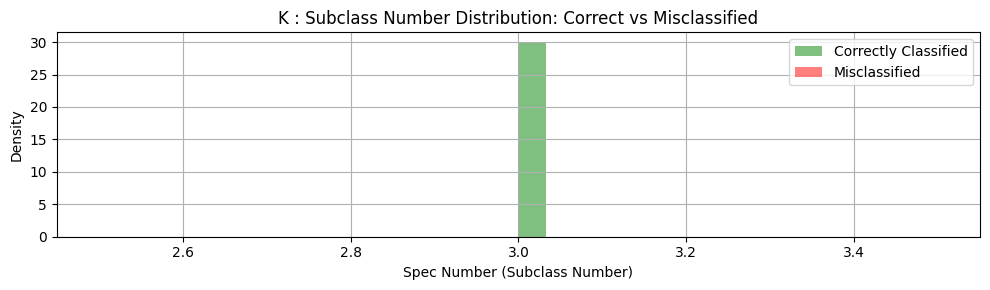

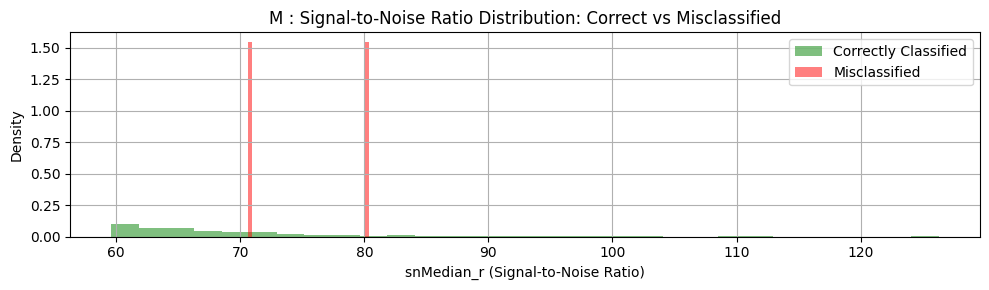

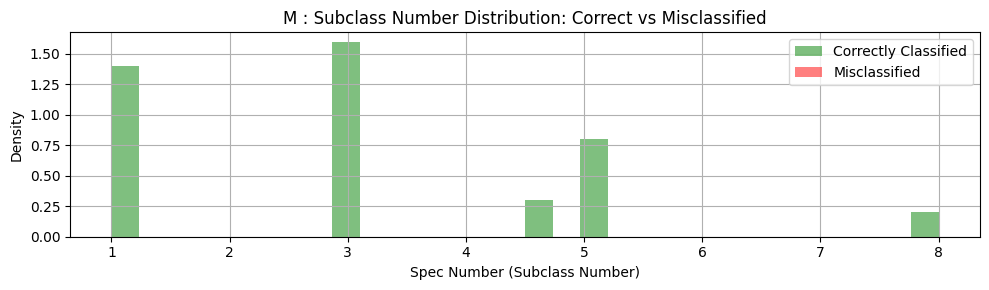

,Major Class,Correct Count,Misclassified Count,Correct Mean snMedian_r,Misclassified Mean snMedian_r,Correct Mean spec_number,Misclassified Mean spec_number
0,O,493,1,40.831252,50.351020,8.004438,NaN
1,B,447,16,48.093397,54.645355,5.141304,6.05
2,A,402,3,96.740829,96.135327,2.818182,NaN
3,F,463,21,113.655702,114.381086,3.500000,NaN
4,G,440,8,102.944239,104.080295,4.300000,0.00
5,K,453,6,112.798757,109.647067,3.000000,NaN
6,M,437,2,68.756853,75.502295,3.058140,NaN


In [119]:
grouped_stats = []
major_classes = ['O', 'B', 'A', 'F', 'G', 'K', 'M']
for cls in major_classes:
    correct_sub = correct_df[correct_df['major_class'] == cls]
    misclassified_sub = misclassified_df[misclassified_df['major_class'] == cls]

    grouped_stats.append({
        'Major Class': cls,
        'Correct Count': len(correct_sub),
        'Misclassified Count': len(misclassified_sub),
        'Correct Mean snMedian_r': correct_sub['snMedian_r'].mean(),
        'Misclassified Mean snMedian_r': misclassified_sub['snMedian_r'].mean(),
        'Correct Mean spec_number': correct_sub['spec_number'].mean(),
        'Misclassified Mean spec_number': misclassified_sub['spec_number'].mean()
    })

    plt.figure(figsize=(10, 3))
    plt.hist(correct_sub['snMedian_r'], bins=30, alpha=0.5, label='Correctly Classified', color='green', density=True)
    plt.hist(misclassified_sub['snMedian_r'], bins=30, alpha=0.5, label='Misclassified', color='red', density=True)
    plt.xlabel('snMedian_r (Signal-to-Noise Ratio)')
    plt.ylabel('Density')
    plt.title(f'{cls} : Signal-to-Noise Ratio Distribution: Correct vs Misclassified')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(10, 3))
    plt.hist(correct_sub['spec_number'].dropna(), bins=30, alpha=0.5, label='Correctly Classified', color='green', density=True)
    plt.hist(misclassified_sub['spec_number'].dropna(), bins=30, alpha=0.5, label='Misclassified', color='red', density=True)
    plt.xlabel('Spec Number (Subclass Number)')
    plt.ylabel('Density')
    plt.title(f'{cls} : Subclass Number Distribution: Correct vs Misclassified')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

grouped_df = pd.DataFrame(grouped_stats)
grouped_df.head(10)

## Test on Additional Data

### Get data

In [117]:
df2 = pd.read_csv(f"{data_dir}/StarSpectra100k.csv")
df2['major_type'] = df2['subclass'].str.extract(r'^([OBAFGKM])')

In [ ]:
fits_data2 = {}
for _, row in df2.iterrows():
    plate, mjd, fiberID, subclass, majorclass = row['plate'], row['mjd'], row['fiberID'], row['subclass'], row['major_type']
    fits_path = f"{data_dir}/raw_fits/spec-{plate}-{mjd}-{fiberID}.fits"
    spectrum = load_local_spectrum(fits_path)
    if spectrum is not None:
        fits_data2[(plate, mjd, fiberID)] = (spectrum, subclass, majorclass)

### Create Features

In [ ]:
X2, y2, idx2 = [], [], []

for (plate, mjd, fiberID), (spectrum, subclass, majorclass) in fits_data2.items():
    X2.append(spectrum)
    y2.append(majorclass)
    idx2.append((plate, mjd, fiberID))

X2 = np.array(X)
y2 = np.array(y)

print(f"Total samples: {len(X2)}, {len(y2)}")

### Normalize

In [ ]:
X_norm2 = []

for flux in X2:
    continuum = continuum_savgol(flux)
    continuum = np.clip(continuum, 1e-5, None)
    norm_flux = flux / continuum
    norm_flux = (norm_flux - np.mean(norm_flux)) / np.std(norm_flux)
    X_norm2.append(norm_flux)

X_norm2 = np.array(X_norm2)

### Check Normalized features

In [ ]:
flux_stats_df = compute_flux_stats(X2)
flux_stats_df_norm = compute_flux_stats(X_norm2)

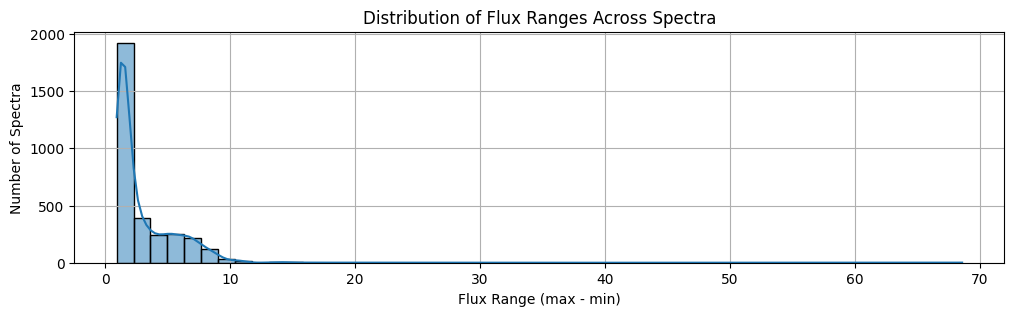

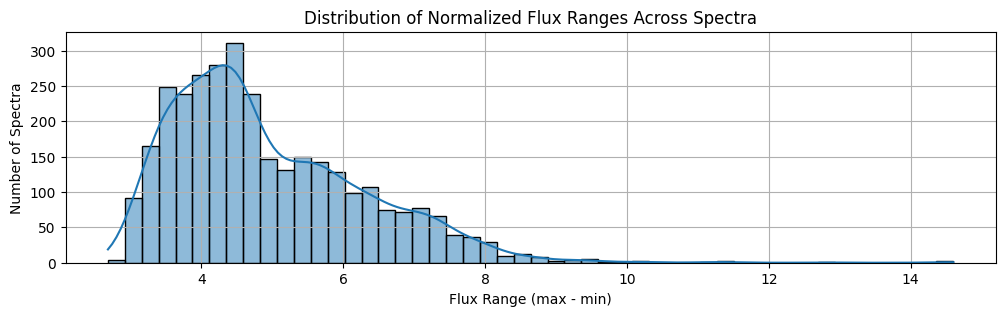

In [ ]:
plt.figure(figsize=(12, 3))
sns.histplot(flux_stats_df['range_flux'], bins=50, kde=True)
plt.title("Distribution of Flux Ranges Across Spectra")
plt.xlabel("Flux Range (max - min)")
plt.ylabel("Number of Spectra")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 3))
sns.histplot(flux_stats_df_norm['range_flux'], bins=50, kde=True)
plt.title("Distribution of Normalized Flux Ranges Across Spectra")
plt.xlabel("Flux Range (max - min)")
plt.ylabel("Number of Spectra")
plt.grid(True)
plt.show()

In [ ]:
class_counts = Counter(y2)
print("Original class counts:")
for label, count in class_counts.items():
    print(f"{label}: {count}")

Original class counts:
B: 463
M: 439
F: 484
O: 493
G: 448
A: 405
K: 459


### Encode Labels

In [ ]:
y_test_enc2 = le.transform(y2)
print("Test class counts:", Counter(y_test_enc2))

Train class counts: Counter({6: 394, 2: 387, 1: 370, 4: 367, 3: 359, 5: 351, 0: 324})
Test class counts: Counter({6: 99, 2: 97, 1: 93, 4: 92, 3: 89, 5: 88, 0: 81})


### Predict

In [ ]:
X_test_cnn = X_norm[..., np.newaxis]
y_pred_probs = model.predict(X_test_cnn)
y_pred = np.argmax(y_pred_probs, axis=1)

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step


### Classification Report

In [ ]:
print("Classification Report:\n")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

Classification Report:

              precision    recall  f1-score   support

           A       0.91      0.88      0.89        81
           B       0.91      0.85      0.88        93
           F       0.80      0.76      0.78        97
           G       0.78      0.89      0.83        89
           K       0.97      0.92      0.94        92
           M       0.98      0.98      0.98        88
           O       0.92      0.98      0.95        99

    accuracy                           0.89       639
   macro avg       0.90      0.89      0.89       639
weighted avg       0.90      0.89      0.89       639



### Confusion Matrix

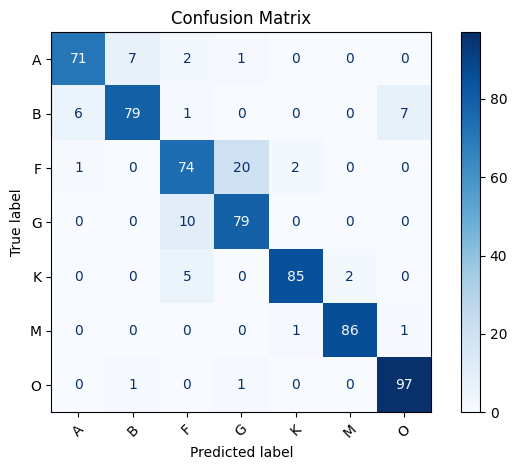

In [ ]:
cm = confusion_matrix(y_test_enc, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

### ROC curve

In [ ]:
# y_pred_probs = model.predict(X_test_cnn) 
class_names = le.classes_

y_bin = label_binarize(y_test_enc, classes=np.arange(len(class_names)))  # shape: (n_samples, n_classes)

fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(10, 4))
for i in range(len(class_names)):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2, label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


### Analyze misclassified

In [ ]:
misclassified_indices_y = np.where(y_pred != y_test_enc)[0]

for i in misclassified_indices_y:
    true_label = le.inverse_transform([y_test_enc[i]])[0]
    pred_label = le.inverse_transform([y_pred[i]])[0]

    plate, mjd, fiberID = idx_test[i]
    spectrum, _, _ = fits_data[(plate, mjd, fiberID)]

    X_normalized_data = X_test[i]
    X_original_data = spectrum

    plot_misclassified(X_original_data, X_normalized_data, true_label, pred_label)